In [ ]:
import pandas as pd
from sklearn.neighbors import KDTree

In [ ]:
df = pd.read_csv("https://bitbucket.org/zeerobug/material/raw/12301e73580ce6b623a7a6fd601c08549eed1c45/datasets/votes_skills_anon.csv", index_col=0)
df.head()

,SUID,univid,response
0,538.0,5c9e7a6834cda4f3677e662b,Internationality
1,2285.0,5c9e373c34cda4f3677e14ef,Practical relevance / professionalization
2,2285.0,5c9e7d8334cda4f3677e6b4f,Internationality
3,2285.0,5e84b8a01ead1a77be3bd3a8,Soft skills and digital literacy
4,2285.0,5c9e471734cda4f3677e2ed7,Internationality


In [ ]:
skills = df.groupby(["univid", "response"])["response"].count().reset_index(name='value')
skills.head()

,univid,response,value
0,5c9e345f34cda4f3677e1047,Academic excellence,10
1,5c9e345f34cda4f3677e1047,Internationality,24
2,5c9e345f34cda4f3677e1047,Practical relevance / professionalization,10
3,5c9e345f34cda4f3677e1047,Soft skills and digital literacy,7
4,5c9e345f34cda4f3677e1047,Specialization,18


In [ ]:
univSkills = skills.pivot_table(values="value", columns="response", index=["univid"])
univSkills.head()

response,Academic excellence,Internationality,Practical relevance / professionalization,Soft skills and digital literacy,Specialization
univid,,,,,
5c9e345f34cda4f3677e1047,10.0,24.0,10.0,7.0,18.0
5c9e349434cda4f3677e109f,5.0,10.0,12.0,9.0,15.0
5c9e34a834cda4f3677e10bd,8.0,10.0,8.0,6.0,8.0
5c9e34ae34cda4f3677e10c7,1.0,17.0,17.0,14.0,17.0
5c9e34d534cda4f3677e1107,10.0,11.0,15.0,10.0,24.0


In [ ]:
univSkills.sum(axis=1).head()


,0
univid,
5c9e345f34cda4f3677e1047,69.0
5c9e349434cda4f3677e109f,51.0
5c9e34a834cda4f3677e10bd,40.0
5c9e34ae34cda4f3677e10c7,66.0
5c9e34d534cda4f3677e1107,70.0


In [ ]:
univSkills = univSkills.div(univSkills.sum(axis=1), axis=0)
univSkills.fillna(0, inplace=True )
univSkills.head()

response,Academic excellence,Internationality,Practical relevance / professionalization,Soft skills and digital literacy,Specialization
univid,,,,,
5c9e345f34cda4f3677e1047,0.144928,0.347826,0.144928,0.101449,0.260870
5c9e349434cda4f3677e109f,0.098039,0.196078,0.235294,0.176471,0.294118
5c9e34a834cda4f3677e10bd,0.200000,0.250000,0.200000,0.150000,0.200000
5c9e34ae34cda4f3677e10c7,0.015152,0.257576,0.257576,0.212121,0.257576
5c9e34d534cda4f3677e1107,0.142857,0.157143,0.214286,0.142857,0.342857


In [ ]:
tree = KDTree(univSkills)
dist, ind = tree.query(univSkills[9:10], k=5)
data_u = univSkills.iloc[ind.tolist()[0]]
data_u.head()
data_u["Academic excellence"]

,Academic excellence
univid,
5c9e35b234cda4f3677e126b,0.047059
5c9e5b5e34cda4f3677e42fb,0.078125
5c9e3fc034cda4f3677e22e3,0.087500
5e8c879823d6684db014ea30,0.074074
5c9e7c4034cda4f3677e6937,0.075472


['Academic excellence',
 'Internationality',
 'Practical relevance / professionalization',
 'Soft skills and digital literacy',
 'Specialization']

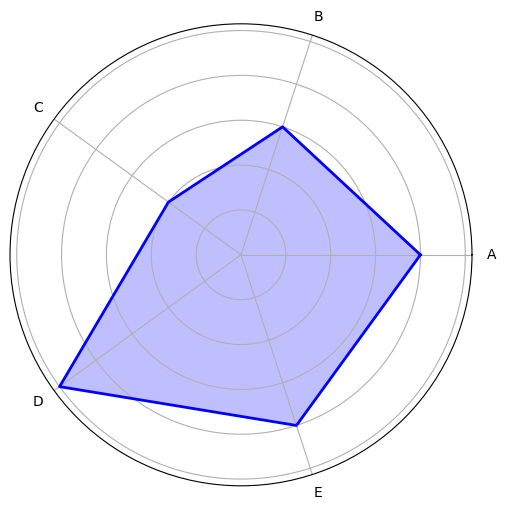

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from math import pi

# Data

categories = data.columns.values.tolist()
values = [4, 3, 2, 5, 4]

# Number of variables
num_vars = len(categories)

# Compute angle for each axis
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()

# The radar chart requires a complete loop, so append the start value to the end
values += values[:1]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

ax.fill(angles, values, color='blue', alpha=0.25)
ax.plot(angles, values, color='blue', linewidth=2)

# Labels for each category
ax.set_yticklabels([])
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)

plt.show()


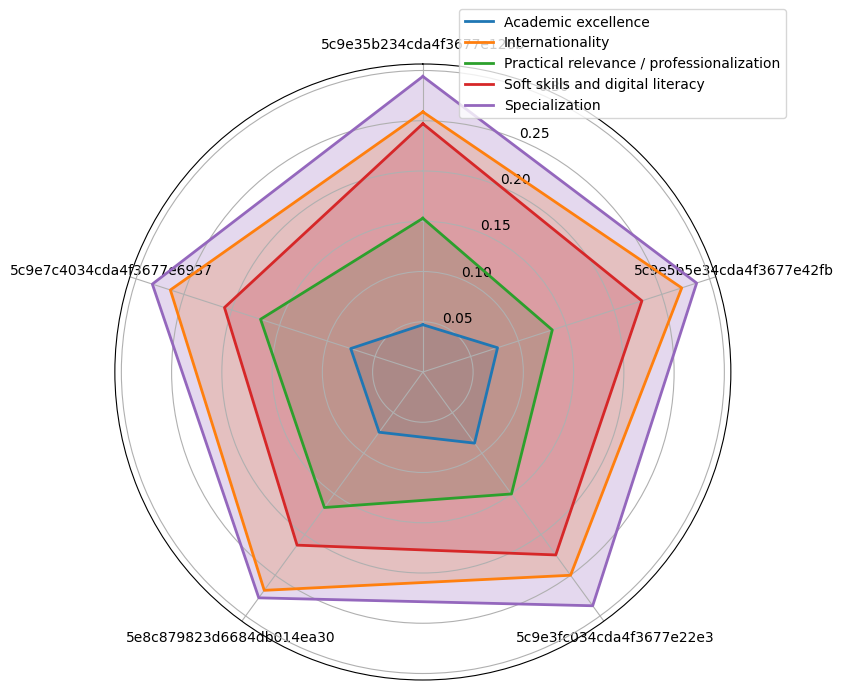

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import pi

# Example DataFrame
data = {
    'Category': ['A', 'B', 'C', 'D', 'E'],
    'Entity1': [4, 3, 2, 5, 4],
    'Entity2': [2, 3, 4, 1, 5],
    'Entity3': [5, 2, 3, 4, 1]
}

df = pd.DataFrame(data)
df = data_u
# df.set_index('univid', inplace=True)
# df.set_index('Category', inplace=True)

# Create a radar chart for each entity
def plot_radar(df):
    # Number of entities
    num_entities = len(df.columns)

    # Number of categories
    num_vars = len(df.index)

    # Compute angle for each axis
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]  # Close the loop

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    # Draw one axe per variable and add labels
    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)
    plt.xticks(angles[:-1], df.index)

    # Plot each entity
    for column in df.columns:
        values = df[column].tolist()
        values += values[:1]  # Close the loop
        ax.plot(angles, values, linewidth=2, linestyle='solid', label=column)
        ax.fill(angles, values, alpha=0.25)

    # Add legend
    plt.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1))

    plt.show()

# Call the function to plot the radar chart
plot_radar(df)


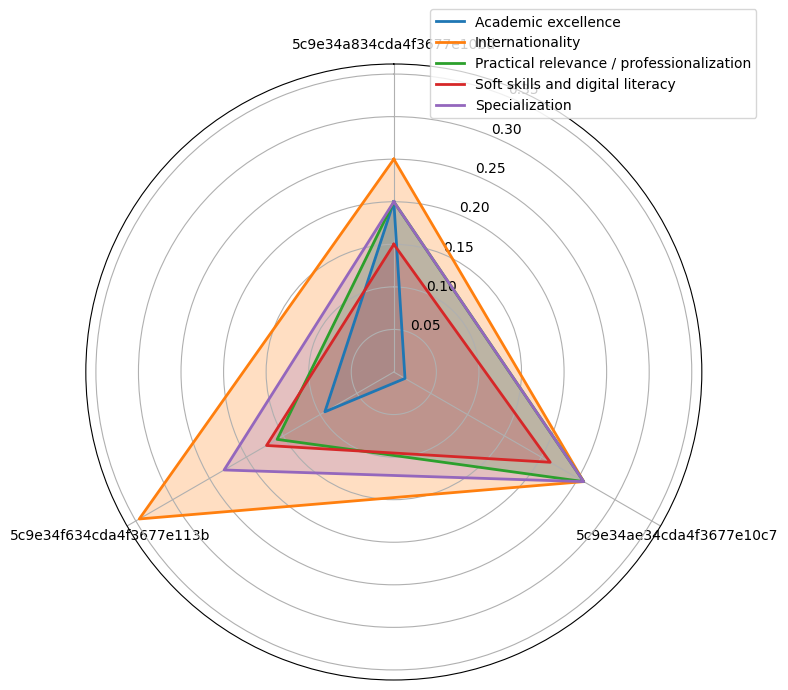

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import pi

# Example DataFrame

df = univSkills.iloc[[2, 3, 5]]
# df.set_index('univid', inplace=True)
# df.set_index('Category', inplace=True)

# Create a radar chart for each entity
def plot_radar(df):
    # Number of entities
    num_entities = len(df.columns)

    # Number of categories
    num_vars = len(df.index)

    # Compute angle for each axis
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]  # Close the loop

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    # Draw one axe per variable and add labels
    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)
    plt.xticks(angles[:-1], df.index)

    # Plot each entity
    for column in df.columns:
        values = df[column].tolist()
        values += values[:1]  # Close the loop
        ax.plot(angles, values, linewidth=2, linestyle='solid', label=column)
        ax.fill(angles, values, alpha=0.25)

    # Add legend
    plt.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1))

    plt.show()

# Call the function to plot the radar chart
plot_radar(df)


In [ ]:
df.head()

,Entity1,Entity2,Entity3
Category,,,
A,4,2,5
B,3,3,2
C,2,4,3
D,5,1,4
E,4,5,1
